# claude-sonnet-4-5 Gabor Orientation Experiment (CCV LiteLLM)

This notebook runs a multimodal 2AFC orientation-discrimination experiment with the current custom parameter grid:
- **Task**: classify Gabor tilt as **CW** vs **CCW** relative to vertical
- **Eccentricity (% of half-width)**: 0, 50
- **External noise levels**: none, high
- **Signed offsets (deg)**: -45, -16, -6, 6, 16, 45
- **Spatial frequency options (cpd)**: 0.4, 0.8, 1.6
- **Contrast amplitudes**: 0.6, 0.8, 1.0

Model is queried through Brown CCV LiteLLM endpoint with `claude-sonnet-4-5`.

In [1]:
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

True

In [2]:
# Core imports
import os
import io
import base64
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

API_KEY = os.getenv("OPENAI_API_KEY")
BASE_URL = os.getenv("LITELLM_BASE_URL", "https://litellm.ccv.brown.edu")
MODEL = "claude-sonnet-4-5"

if not API_KEY:
    raise RuntimeError("OPENAI_API_KEY not found in .env.")

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
print(f"Using endpoint: {BASE_URL}")
print(f"Using model: {MODEL}")

Using endpoint: https://litellm.ccv.brown.edu
Using model: claude-sonnet-4-5


In [24]:
# Experiment design constants
ECCENTRICITIES_PCT = [0, 50]

# External noise standard deviation by condition (image intensity scale 0..1).
NOISE_SIGMA = {
    "none": 0.00,
    "low": 0.02,
    # "medium": 0.06,
    "high": 0.12,
}

# Keep NOISE_LEVELS synced to NOISE_SIGMA keys to avoid KeyError at runtime.
NOISE_LEVELS = list(NOISE_SIGMA.keys())
ORIENTATION_OFFSETS_DEG = [-45, 
                           -16, -6, 6, 16, 
                           45]

# Spatial frequency setup (cycles per degree).
PAPER_SPATIAL_FREQ_CPD = 3.0
SPATIAL_FREQ_OPTIONS_CPD = [0.4,
                            0.8,
                            1.6]

# Gabor contrast amplitudes around gray background (0.5).
GABOR_CONTRAST_OPTIONS = [0.6, 
                          0.8, 
                          1.0]

# Each offset is repeated within each eccentricity x noise x frequency x contrast condition.
REPEATS_PER_OFFSET = 5

# Safety cap for API usage during testing. Set to an int like 120 for quick smoke runs.
MAX_TRIALS = None

# Reverted to a 256 x 256 canvas.
IMAGE_WIDTH = 256
IMAGE_HEIGHT = 256
PATCH_SIZE = 72
PIXELS_PER_DEGREE = 12.0
SEED = 1950

rng = np.random.default_rng(SEED)

In [25]:
# Gabor synthesis utilities (adapted to match this notebook pipeline).
def make_gabor_patch(
    size: int,
    orientation_deg_from_x: float,
    spatial_freq_cycles_per_px: float,
    sigma_px: float = 16.0,
    phase_rad: float = 0.0,
) -> np.ndarray:
    """
    Create a sinusoidal grating under a Gaussian envelope.
    orientation_deg_from_x is measured in image coordinates from x-axis.
    """
    coords = np.arange(size) - (size - 1) / 2.0
    x, y = np.meshgrid(coords, coords)

    theta = np.deg2rad(orientation_deg_from_x)
    x_theta = x * np.cos(theta) + y * np.sin(theta)

    sinusoid = np.cos(2 * np.pi * spatial_freq_cycles_per_px * x_theta + phase_rad)
    envelope = np.exp(-(x**2 + y**2) / (2 * sigma_px**2))
    gabor = sinusoid * envelope
    return gabor


def render_trial_image(
    offset_deg: float,
    eccentricity_pct: float,
    noise_level: str,
    side: int,
    spatial_freq_cpd: float,
    contrast_amplitude: float,
    image_width: int = IMAGE_WIDTH,
    image_height: int = IMAGE_HEIGHT,
    patch_size: int = PATCH_SIZE,
    pixels_per_degree: float = PIXELS_PER_DEGREE,
    rng: np.random.Generator = rng,
) -> np.ndarray:
    """
    Build one stimulus image with:
    - a Gabor patch at chosen eccentricity (left/right of fixation)
    - additive Gaussian external noise
    - a central fixation cross
    
    eccentricity_pct is interpreted as a percent of half-screen horizontal distance
    from fixation to the image edge (e.g., 10 means 10% of half-width).
    """
    image = np.full((image_height, image_width), 0.5, dtype=float)

    # In this construction, theta=0 produces a vertical Gabor (baseline).
    # Positive offset is CW from vertical, which maps to negative theta.
    orientation_deg_from_x = -offset_deg

    # Convert cycles/degree to cycles/pixel using the display sampling assumption.
    spatial_freq_cycles_per_px = spatial_freq_cpd / pixels_per_degree

    patch = make_gabor_patch(
        size=patch_size,
        orientation_deg_from_x=orientation_deg_from_x,
        spatial_freq_cycles_per_px=spatial_freq_cycles_per_px,
        sigma_px=patch_size * 0.22,
        phase_rad=float(rng.uniform(0, 2 * np.pi)),
    )

    # Map from [-1,1]-ish to visible grayscale contrast around 0.5.
    patch = 0.5 + contrast_amplitude * patch

    ecc_px = int(round((image_width / 2) * (eccentricity_pct / 100.0)))
    cy = image_height // 2
    cx = image_width // 2 + side * ecc_px

    half = patch_size // 2
    y0, y1 = cy - half, cy - half + patch_size
    x0, x1 = cx - half, cx - half + patch_size

    if y0 < 0 or x0 < 0 or y1 > image_height or x1 > image_width:
        raise ValueError("Patch out of bounds. Reduce eccentricity_pct or patch size.")

    image[y0:y1, x0:x1] = patch

    sigma = NOISE_SIGMA[noise_level]
    image += rng.normal(0.0, sigma, size=image.shape)

    # Draw fixation cross so the intended reference point is explicit.
    c_y = image_height // 2
    c_x = image_width // 2
    image[c_y - 10:c_y + 11, c_x - 1:c_x + 2] = 0.1
    image[c_y - 1:c_y + 2, c_x - 10:c_x + 11] = 0.1

    return np.clip(image, 0.0, 1.0)


def image_to_data_url(image: np.ndarray) -> str:
    """Encode a numpy image into a PNG data URL for the multimodal API call."""
    buf = io.BytesIO()
    plt.imsave(buf, image, cmap="gray", vmin=0.0, vmax=1.0, format="png")
    encoded = base64.b64encode(buf.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{encoded}"

Canvas: 256 x 256
Eccentricity levels (% of half-width): [0, 50]
Paper spatial frequency: 3.0 cpd
Spatial frequency options: [0.4, 0.8, 1.6]
Gabor contrast options: [0.6, 0.8, 1.0]
Sanity-check frequency: 1.6 cpd
Sanity-check contrast amplitude: 1.00
Lowest noise: none (sigma=0.000)
Highest noise: high (sigma=0.120)


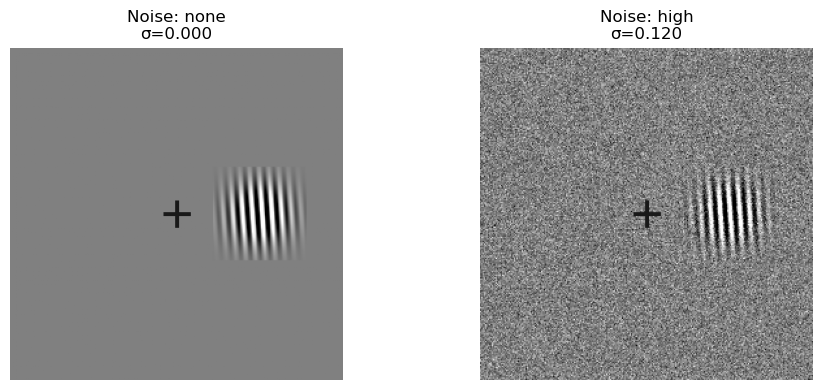

In [26]:
# Quick sanity check: visualize and print the lowest vs highest noise conditions.
lowest_noise = min(NOISE_SIGMA, key=NOISE_SIGMA.get)
highest_noise = max(NOISE_SIGMA, key=NOISE_SIGMA.get)
demo_freq = SPATIAL_FREQ_OPTIONS_CPD[-1]
demo_contrast = GABOR_CONTRAST_OPTIONS[-1]

print(f"Canvas: {IMAGE_WIDTH} x {IMAGE_HEIGHT}")
print(f"Eccentricity levels (% of half-width): {ECCENTRICITIES_PCT}")
print(f"Paper spatial frequency: {PAPER_SPATIAL_FREQ_CPD:.1f} cpd")
print(f"Spatial frequency options: {SPATIAL_FREQ_OPTIONS_CPD}")
print(f"Gabor contrast options: {GABOR_CONTRAST_OPTIONS}")
print(f"Sanity-check frequency: {demo_freq:.1f} cpd")
print(f"Sanity-check contrast amplitude: {demo_contrast:.2f}")
print(f"Lowest noise: {lowest_noise} (sigma={NOISE_SIGMA[lowest_noise]:.3f})")
print(f"Highest noise: {highest_noise} (sigma={NOISE_SIGMA[highest_noise]:.3f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, noise in zip(axes, [lowest_noise, highest_noise]):
    img = render_trial_image(
        offset_deg=4,
        eccentricity_pct=50,
        noise_level=noise,
        side=1,
        spatial_freq_cpd=demo_freq,
        contrast_amplitude=demo_contrast,
    )
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Noise: {noise}\nσ={NOISE_SIGMA[noise]:.3f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
# Trial table + model query functions
def build_trial_table(repeats_per_offset: int, rng: np.random.Generator) -> pd.DataFrame:
    """Create a shuffled factorial trial table with explicit offset and factor coverage per condition."""
    rows = []
    for ecc_pct in ECCENTRICITIES_PCT:
        for noise in NOISE_LEVELS:
            for spatial_freq_cpd in SPATIAL_FREQ_OPTIONS_CPD:
                for contrast_amplitude in GABOR_CONTRAST_OPTIONS:
                    for offset in ORIENTATION_OFFSETS_DEG:
                        for _ in range(repeats_per_offset):
                            side = int(rng.choice([-1, 1]))
                            rows.append({
                                "eccentricity_pct": int(ecc_pct),
                                "noise_level": noise,
                                "spatial_freq_cpd": float(spatial_freq_cpd),
                                "contrast_amplitude": float(contrast_amplitude),
                                "offset_deg": int(offset),
                                "side": side,
                            })
    df = pd.DataFrame(rows)
    return df.sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).reset_index(drop=True)


def parse_model_choice(text: str):
    """Robustly normalize model output to CW/CCW labels."""
    if text is None:
        return None
    cleaned = text.strip().upper().replace("-", " ")
    if "COUNTERCLOCKWISE" in cleaned or "CCW" in cleaned:
        return "CCW"
    if "CLOCKWISE" in cleaned or "CW" in cleaned:
        return "CW"
    return None


def query_model_choice(client: OpenAI, model: str, image_data_url: str):
    """Send one stimulus to model and return parsed choice + raw response."""
    prompt = (
        "You are doing a 2AFC visual discrimination task. "
        "A single Gabor patch is shown. "
        "Judge whether the patch is tilted clockwise or counterclockwise relative to vertical. "
        "Respond with exactly one word, one token: CW or CCW. (No explanations, just the choice.)"
    )

    response = client.chat.completions.create(
        model=model,
        messages=[{
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_data_url}},
            ],
        }],
        temperature=0,
        reasoning_effort=None,
    )

    raw = response.choices[0].message.content or ""
    return parse_model_choice(raw), raw

In [31]:
# Run experiment
trials = build_trial_table(REPEATS_PER_OFFSET, rng)
if MAX_TRIALS is not None:
    trials = trials.head(MAX_TRIALS).copy()

print(f"Total planned trials: {len(trials)}")
print("(formula before cap: eccentricities x noise levels x spatial frequencies x contrast amplitudes x orientation offsets x repeats)")
print(f"= {len(ECCENTRICITIES_PCT)} x {len(NOISE_LEVELS)} x {len(SPATIAL_FREQ_OPTIONS_CPD)} x {len(GABOR_CONTRAST_OPTIONS)} x {len(ORIENTATION_OFFSETS_DEG)} x {REPEATS_PER_OFFSET}")

records = []
for i, row in tqdm(trials.iterrows(), total=len(trials), desc="Running trials"):
    offset = float(row["offset_deg"] )
    ecc_pct = float(row["eccentricity_pct"] )
    noise = str(row["noise_level"] )
    spatial_freq_cpd = float(row["spatial_freq_cpd"] )
    contrast_amplitude = float(row["contrast_amplitude"] )
    side = int(row["side"] )

    stim = render_trial_image(
        offset_deg=offset,
        eccentricity_pct=ecc_pct,
        noise_level=noise,
        side=side,
        spatial_freq_cpd=spatial_freq_cpd,
        contrast_amplitude=contrast_amplitude,
    )

    data_url = image_to_data_url(stim)
    true_choice = "CW" if offset > 0 else "CCW"

    model_choice, model_raw_text, api_error = None, "", None
    try:
        model_choice, model_raw_text = query_model_choice(client, MODEL, data_url)
    except Exception as exc:
        api_error = str(exc)

    correct = None if model_choice is None else int(model_choice == true_choice)

    records.append({
        "trial": int(i),
        "eccentricity_pct": ecc_pct,
        "noise_level": noise,
        "spatial_freq_cpd": spatial_freq_cpd,
        "contrast_amplitude": contrast_amplitude,
        "offset_deg": offset,
        "abs_offset_deg": abs(offset),
        "side": side,
        "true_choice": true_choice,
        "model_choice": model_choice,
        "model_raw_text": model_raw_text,
        "correct": correct,
        "api_error": api_error,
    })

df = pd.DataFrame(records)

# # Save run data immediately so pilot runs are not lost.
# output_dir = Path("results/claude_sonnet45_gabor_notebook")
# output_dir.mkdir(parents=True, exist_ok=True)
# pilot_filename = "pilot_trial_results.csv" if MAX_TRIALS is not None else "full_trial_results.csv"
# df.to_csv(output_dir / pilot_filename, index=False)
# print(f"Saved run data to {output_dir / pilot_filename}")

df.head()

Total planned trials: 1620
(formula before cap: eccentricities x noise levels x spatial frequencies x contrast amplitudes x orientation offsets x repeats)
= 2 x 3 x 3 x 3 x 6 x 5


Running trials: 100%|██████████| 1620/1620 [33:46<00:00,  1.25s/it] 


,trial,eccentricity_pct,noise_level,spatial_freq_cpd,contrast_amplitude,offset_deg,abs_offset_deg,side,true_choice,model_choice,model_raw_text,correct,api_error
0,0,50.0,low,0.8,0.6,-6.0,6.0,-1,CCW,CW,CW,0,None
1,1,50.0,none,1.6,1.0,16.0,16.0,1,CW,CW,CW,1,None
2,2,0.0,low,0.4,0.8,-16.0,16.0,1,CCW,CW,CW,0,None
3,3,0.0,low,0.8,0.6,45.0,45.0,-1,CW,CW,CW,1,None
4,4,50.0,high,0.4,0.8,-16.0,16.0,1,CCW,CW,CW,0,None


In [32]:
# Analysis utilities
def estimate_threshold_75(group: pd.DataFrame):
    """
    Coarse threshold estimate: smallest |offset| where accuracy >= 0.75.
    """
    curve = (
        group.groupby("abs_offset_deg", as_index=False)["correct"]
        .mean()
        .sort_values("abs_offset_deg")
        .reset_index(drop=True)
    )
    hits = curve[curve["correct"] >= 0.75]
    return None if hits.empty else float(hits.iloc[0]["abs_offset_deg"])


valid_df = df[df["correct"].notna()].copy()
print(f"Valid parsed trials: {len(valid_df)} / {len(df)}")

# Full factorial accuracy summary includes all manipulated variables.
condition_acc = (
    valid_df.groupby([
        "eccentricity_pct",
        "noise_level",
        "spatial_freq_cpd",
        "contrast_amplitude",
    ], as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)

# Marginal effects: one per variable.
marginal_ecc = (
    valid_df.groupby("eccentricity_pct", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)
marginal_noise = (
    valid_df.groupby("noise_level", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)
marginal_freq = (
    valid_df.groupby("spatial_freq_cpd", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)
marginal_contrast = (
    valid_df.groupby("contrast_amplitude", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)
marginal_offset = (
    valid_df.groupby("abs_offset_deg", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)
marginal_signed_offset = (
    valid_df.groupby("offset_deg", as_index=False)["correct"]
    .mean()
    .rename(columns={"correct": "accuracy"})
)

# Build thresholds in a version-stable way.
threshold_rows = []
for (ecc, noise, freq, contrast), group in valid_df.groupby([
    "eccentricity_pct",
    "noise_level",
    "spatial_freq_cpd",
    "contrast_amplitude",
]):
    threshold_rows.append({
        "eccentricity_pct": ecc,
        "noise_level": noise,
        "spatial_freq_cpd": freq,
        "contrast_amplitude": contrast,
        "threshold_75_deg": estimate_threshold_75(group[["abs_offset_deg", "correct"]]),
    })
thresholds = pd.DataFrame(threshold_rows)

print("Marginal: eccentricity")
display(marginal_ecc.sort_values("eccentricity_pct"))
print("Marginal: noise")
display(marginal_noise.set_index("noise_level").reindex(NOISE_LEVELS).reset_index())
print("Marginal: spatial frequency")
display(marginal_freq.sort_values("spatial_freq_cpd"))
print("Marginal: contrast amplitude")
display(marginal_contrast.sort_values("contrast_amplitude"))
print("Marginal: |offset|")
display(marginal_offset.sort_values("abs_offset_deg"))
print("Marginal: signed offset")
display(marginal_signed_offset.sort_values("offset_deg"))
print("Accuracy by full condition")
display(condition_acc)
print("Thresholds by full condition")
display(thresholds)

Valid parsed trials: 1620 / 1620
Marginal: eccentricity


,eccentricity_pct,accuracy
0,0.0,0.491358
1,50.0,0.487654


Marginal: noise


,noise_level,accuracy
0,none,0.487037
1,low,0.503704
2,high,0.477778


Marginal: spatial frequency


...

,offset_deg,accuracy
0,-45.0,0.162963
1,-16.0,0.196296
2,-6.0,0.270370
3,6.0,0.714815
4,16.0,0.777778
5,45.0,0.814815


Accuracy by full condition


,eccentricity_pct,noise_level,spatial_freq_cpd,contrast_amplitude,accuracy
0,0.0,high,0.4,0.6,0.500000
1,0.0,high,0.4,0.8,0.500000
2,0.0,high,0.4,1.0,0.600000
3,0.0,high,0.8,0.6,0.366667
4,0.0,high,0.8,0.8,0.466667
5,0.0,high,0.8,1.0,0.500000
6,0.0,high,1.6,0.6,0.566667
7,0.0,high,1.6,0.8,0.466667
8,0.0,high,1.6,1.0,0.400000
9,0.0,low,0.4,0.6,0.500000


Thresholds by full condition


,eccentricity_pct,noise_level,spatial_freq_cpd,contrast_amplitude,threshold_75_deg
0,0.0,high,0.4,0.6,NaN
1,0.0,high,0.4,0.8,NaN
2,0.0,high,0.4,1.0,NaN
3,0.0,high,0.8,0.6,NaN
4,0.0,high,0.8,0.8,NaN
5,0.0,high,0.8,1.0,NaN
6,0.0,high,1.6,0.6,NaN
7,0.0,high,1.6,0.8,NaN
8,0.0,high,1.6,1.0,NaN
9,0.0,low,0.4,0.6,NaN


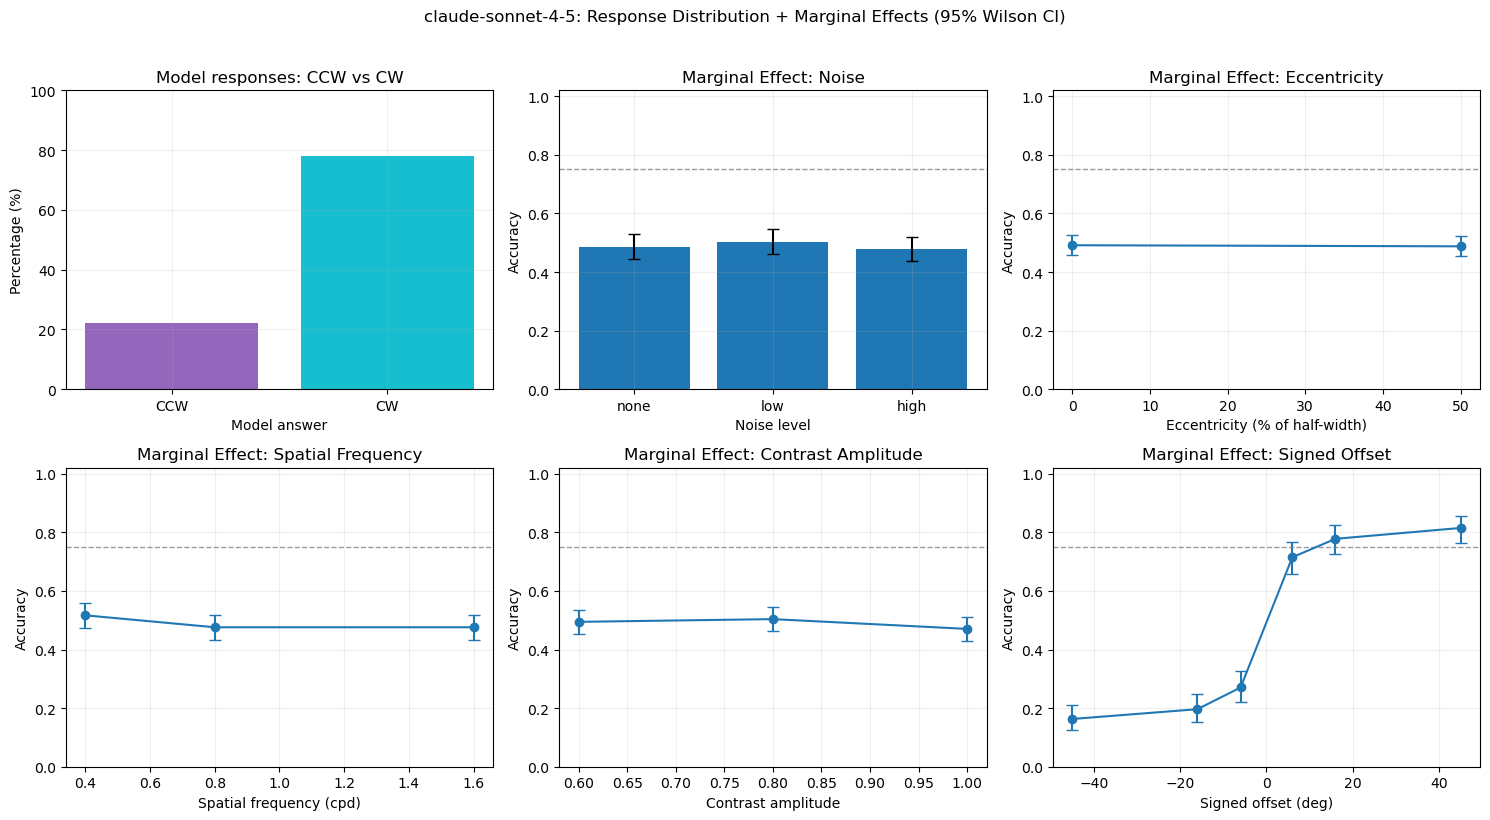

In [37]:
# Marginal effect plots with uncertainty bands (95% Wilson confidence intervals)
output_dir = Path("results/claude_sonnet45_gabor_notebook")
candidate_paths = [
    output_dir / "full_trial_results.csv",
    output_dir / "trial_results.csv",
]
source_path = next((p for p in candidate_paths if p.exists()), None)
if source_path is None:
    tried = ', '.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(f"Could not find any trial-results file. Tried: {tried}")

df_source = pd.read_csv(source_path)
valid_df = df_source[df_source["correct"].notna()].copy()
if valid_df.empty:
    raise ValueError(f"No valid rows found in {source_path.name}.")

if "model_choice" not in valid_df.columns:
    raise ValueError(f"{source_path.name} is missing required column: model_choice")

noise_order_default = ["none", "low", "medium", "high", "very_high"]
noise_levels_present = valid_df["noise_level"].dropna().astype(str).unique().tolist()
noise_order = [n for n in noise_order_default if n in noise_levels_present]
noise_order += [n for n in sorted(noise_levels_present) if n not in noise_order]

def marginal_with_wilson_ci(df: pd.DataFrame, factor: str, z: float = 1.959963984540054) -> pd.DataFrame:
    agg = (
        df.groupby(factor, as_index=False)["correct"]
        .agg(successes="sum", n="count")
        .reset_index(drop=True)
    )
    agg["accuracy"] = agg["successes"] / agg["n"]

    p = agg["accuracy"]
    n = agg["n"]
    denom = 1 + (z**2) / n
    center = (p + (z**2) / (2 * n)) / denom
    half_width = z * np.sqrt((p * (1 - p) + (z**2) / (4 * n)) / n) / denom

    agg["ci_lower"] = np.clip(center - half_width, 0.0, 1.0)
    agg["ci_upper"] = np.clip(center + half_width, 0.0, 1.0)
    agg["yerr_low"] = agg["accuracy"] - agg["ci_lower"]
    agg["yerr_high"] = agg["ci_upper"] - agg["accuracy"]
    return agg

choice_pct = (
    valid_df["model_choice"]
    .astype(str)
    .str.upper()
    .value_counts(normalize=True)
    .reindex(["CCW", "CW"], fill_value=0.0)
    * 100.0
)

noise_plot = marginal_with_wilson_ci(valid_df, "noise_level").set_index("noise_level").reindex(noise_order).reset_index()
ecc_plot = marginal_with_wilson_ci(valid_df, "eccentricity_pct").sort_values("eccentricity_pct")
freq_plot = marginal_with_wilson_ci(valid_df, "spatial_freq_cpd").sort_values("spatial_freq_cpd")
contrast_plot = marginal_with_wilson_ci(valid_df, "contrast_amplitude").sort_values("contrast_amplitude")
signed_offset_plot = marginal_with_wilson_ci(valid_df, "offset_deg").sort_values("offset_deg")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

# 1) CCW vs CW response percentage
axes[0].bar(choice_pct.index, choice_pct.values, color=["tab:purple", "tab:cyan"])
axes[0].set_title("Model responses: CCW vs CW")
axes[0].set_xlabel("Model answer")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_ylim(0, 100)

# 2) Noise (categorical)
x_noise = np.arange(len(noise_plot))
axes[1].bar(
    x_noise,
    noise_plot["accuracy"],
    yerr=np.vstack([noise_plot["yerr_low"], noise_plot["yerr_high"]]),
    capsize=4,
    )
axes[1].set_xticks(x_noise)
axes[1].set_xticklabels(noise_plot["noise_level"])
axes[1].set_title("Marginal Effect: Noise")
axes[1].set_xlabel("Noise level")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.02)

# 3) Eccentricity (numeric)
axes[2].errorbar(
    ecc_plot["eccentricity_pct"],
    ecc_plot["accuracy"],
    yerr=np.vstack([ecc_plot["yerr_low"], ecc_plot["yerr_high"]]),
    marker="o",
    capsize=4,
    linestyle="-",
)
axes[2].set_title("Marginal Effect: Eccentricity")
axes[2].set_xlabel("Eccentricity (% of half-width)")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1.02)

# 4) Spatial frequency (numeric)
axes[3].errorbar(
    freq_plot["spatial_freq_cpd"],
    freq_plot["accuracy"],
    yerr=np.vstack([freq_plot["yerr_low"], freq_plot["yerr_high"]]),
    marker="o",
    capsize=4,
    linestyle="-",
)
axes[3].set_title("Marginal Effect: Spatial Frequency")
axes[3].set_xlabel("Spatial frequency (cpd)")
axes[3].set_ylabel("Accuracy")
axes[3].set_ylim(0, 1.02)

# 5) Contrast amplitude (numeric)
axes[4].errorbar(
    contrast_plot["contrast_amplitude"],
    contrast_plot["accuracy"],
    yerr=np.vstack([contrast_plot["yerr_low"], contrast_plot["yerr_high"]]),
    marker="o",
    capsize=4,
    linestyle="-",
)
axes[4].set_title("Marginal Effect: Contrast Amplitude")
axes[4].set_xlabel("Contrast amplitude")
axes[4].set_ylabel("Accuracy")
axes[4].set_ylim(0, 1.02)

# 6) Signed offset (numeric)
axes[5].errorbar(
    signed_offset_plot["offset_deg"],
    signed_offset_plot["accuracy"],
    yerr=np.vstack([signed_offset_plot["yerr_low"], signed_offset_plot["yerr_high"]]),
    marker="o",
    capsize=4,
    linestyle="-",
)
axes[5].set_title("Marginal Effect: Signed Offset")
axes[5].set_xlabel("Signed offset (deg)")
axes[5].set_ylabel("Accuracy")
axes[5].set_ylim(0, 1.02)

for i, ax in enumerate(axes):
    if i != 0:
        ax.axhline(0.75, linestyle="--", linewidth=1, color="gray", alpha=0.8)
    ax.grid(alpha=0.2)

fig.suptitle("claude-sonnet-4-5: Response Distribution + Marginal Effects (95% Wilson CI)", y=1.02)
plt.tight_layout()
plt.show()

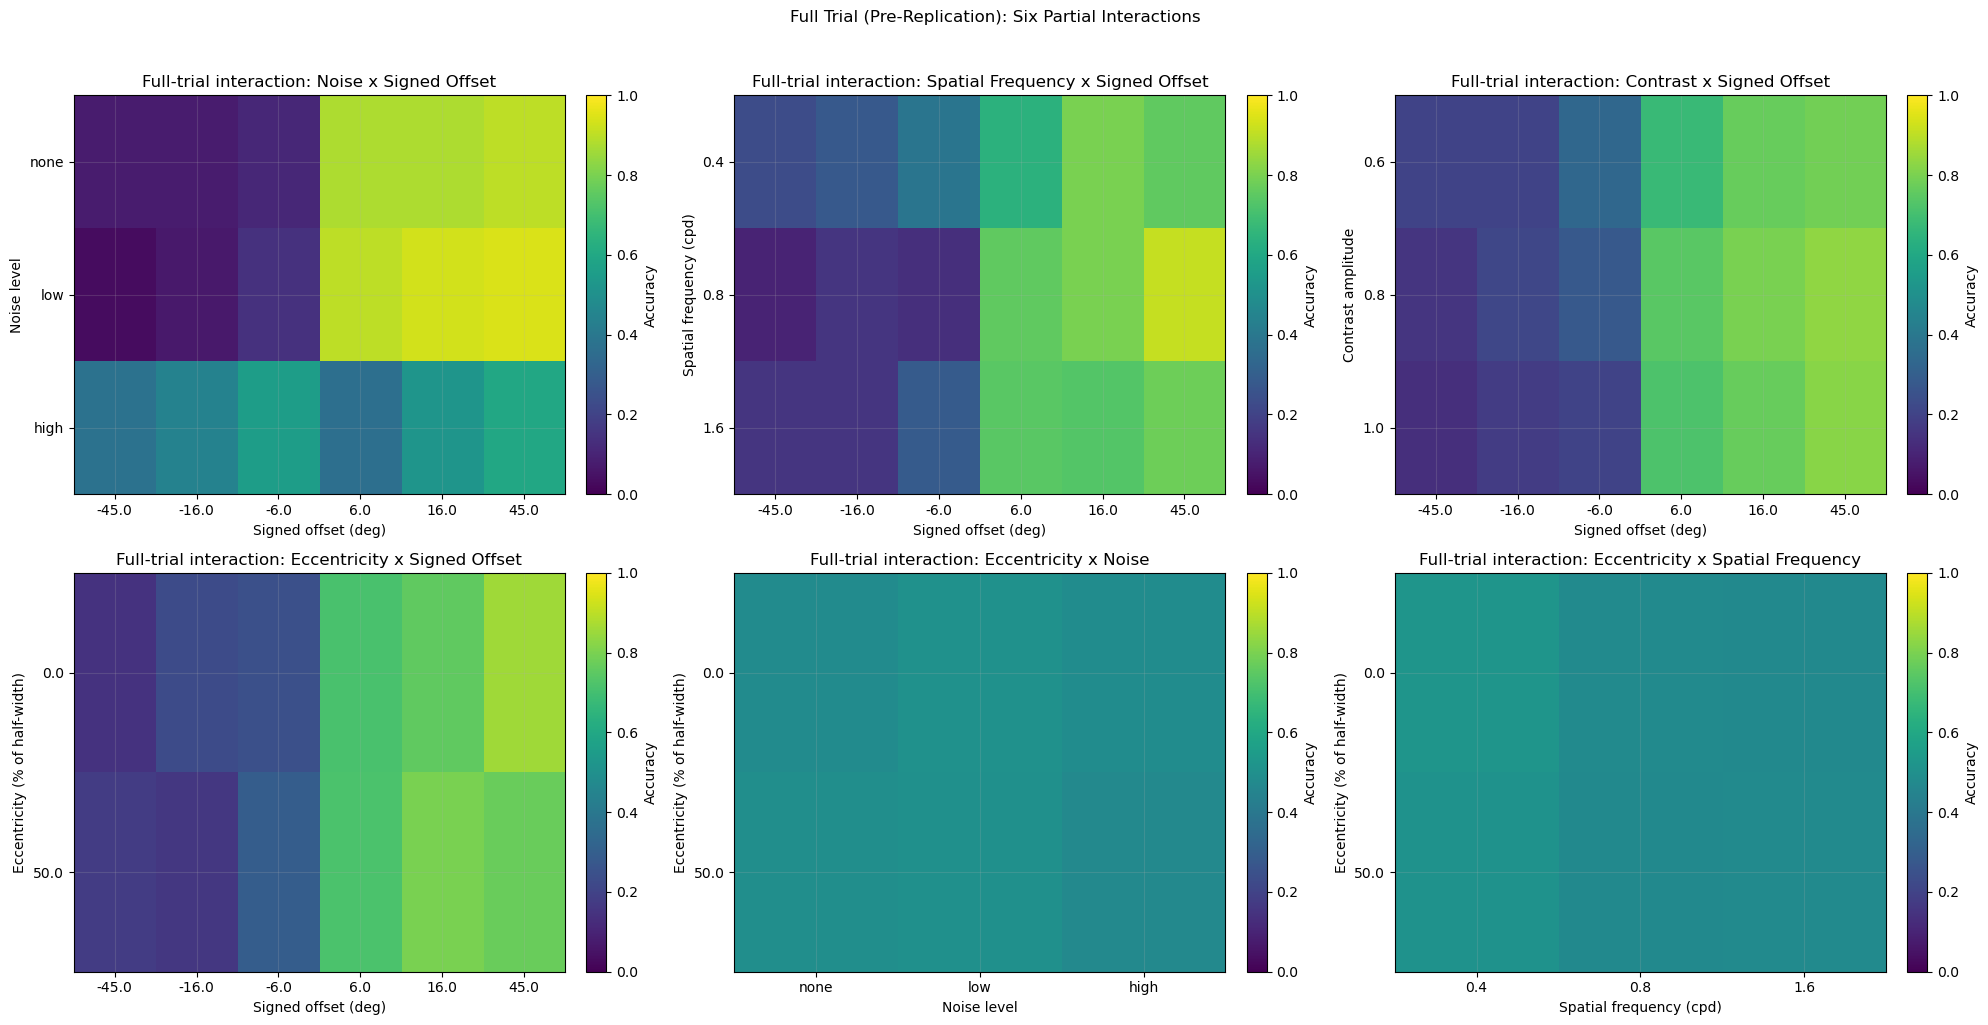

In [39]:
# Full-trial (pre-replication) dashboard: six partial interactions
output_dir = Path("results/claude_sonnet45_gabor_notebook")
candidate_paths = [
    output_dir / "full_trial_results.csv",
    output_dir / "trial_results.csv",
]
trial_results_path = next((p for p in candidate_paths if p.exists()), None)

if trial_results_path is None:
    tried = ', '.join(str(p) for p in candidate_paths)
    raise FileNotFoundError(
        f"Could not find any trial-results file. Tried: {tried}. Run the experiment/save-output cells first."
    )

full_trial = pd.read_csv(trial_results_path)
full_valid = full_trial[full_trial["correct"].notna()].copy()
if full_valid.empty:
    raise ValueError(f"No valid full-trial rows found in {trial_results_path.name}.")

required_cols = {
    "eccentricity_pct", "noise_level", "spatial_freq_cpd", "contrast_amplitude",
    "offset_deg", "correct"
}
missing = required_cols.difference(full_valid.columns)
if missing:
    raise ValueError(f"{trial_results_path.name} is missing columns: {sorted(missing)}")

noise_order_default = ["none", "low", "medium", "high", "very_high"]
noise_levels_present = full_valid["noise_level"].dropna().astype(str).unique().tolist()
noise_order = [n for n in noise_order_default if n in noise_levels_present]
noise_order += [n for n in sorted(noise_levels_present) if n not in noise_order]

def full_acc_by(group_cols):
    g = full_valid.groupby(group_cols, as_index=False)["correct"].agg(successes="sum", n_valid="count")
    g["accuracy"] = g["successes"] / g["n_valid"]
    return g

def full_prep_heatmap(row_col, col_col):
    hm = full_acc_by([row_col, col_col]).copy()
    if row_col == "noise_level":
        hm[row_col] = pd.Categorical(hm[row_col], categories=noise_order, ordered=True)
    if col_col == "noise_level":
        hm[col_col] = pd.Categorical(hm[col_col], categories=noise_order, ordered=True)
    hm = hm.sort_values([row_col, col_col])
    return hm.pivot(index=row_col, columns=col_col, values="accuracy")

# Six requested full-trial interaction plots
pivot_noise_offset = full_prep_heatmap("noise_level", "offset_deg")
pivot_freq_offset = full_prep_heatmap("spatial_freq_cpd", "offset_deg")
pivot_contrast_offset = full_prep_heatmap("contrast_amplitude", "offset_deg")
pivot_ecc_offset = full_prep_heatmap("eccentricity_pct", "offset_deg")
pivot_freq_contrast = full_prep_heatmap("eccentricity_pct", "noise_level")
pivot_noise_freq = full_prep_heatmap("eccentricity_pct", "spatial_freq_cpd")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

heatmaps = [
    (pivot_noise_offset, "Noise x Signed Offset", "Signed offset (deg)", "Noise level"),
    (pivot_freq_offset, "Spatial Frequency x Signed Offset", "Signed offset (deg)", "Spatial frequency (cpd)"),
    (pivot_contrast_offset, "Contrast x Signed Offset", "Signed offset (deg)", "Contrast amplitude"),
    (pivot_ecc_offset, "Eccentricity x Signed Offset", "Signed offset (deg)", "Eccentricity (% of half-width)"),
    (pivot_freq_contrast, "Eccentricity x Noise", "Noise level", "Eccentricity (% of half-width)"),
    (pivot_noise_freq, "Eccentricity x Spatial Frequency", "Spatial frequency (cpd)", "Eccentricity (% of half-width)"),
]

for idx, (pivot_df, title, xlabel, ylabel) in enumerate(heatmaps):
    im = axes[idx].imshow(pivot_df.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    axes[idx].set_title(f"Full-trial interaction: {title}")
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel(ylabel)
    axes[idx].set_xticks(np.arange(len(pivot_df.columns)))
    axes[idx].set_xticklabels([str(c) for c in pivot_df.columns])
    axes[idx].set_yticks(np.arange(len(pivot_df.index)))
    axes[idx].set_yticklabels([str(i) for i in pivot_df.index])
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="Accuracy")

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle("Full Trial (Pre-Replication): Six Partial Interactions", y=1.02)
plt.tight_layout()
plt.show()

In [40]:
# Identify full condition combinations above an arbitrary mean-accuracy threshold
ACCURACY_THRESHOLD = 0.75  # adjust as needed

combo_acc = (
    valid_df.groupby(
        [
            "eccentricity_pct",
            "noise_level",
            "spatial_freq_cpd",
            "contrast_amplitude",
            "offset_deg",
        ],
        as_index=False,
    )["correct"]
    .agg(accuracy="mean", n_trials="count")
    .sort_values(["accuracy", "n_trials"], ascending=[False, False])
    .reset_index(drop=True)
)

high_performing = combo_acc[combo_acc["accuracy"] >= ACCURACY_THRESHOLD].copy()

print(f"Threshold: {ACCURACY_THRESHOLD:.0%}")
print(f"Combinations meeting threshold: {len(high_performing)} / {len(combo_acc)}")

if high_performing.empty:
    print("No full condition combinations met the threshold.")
else:
    display(high_performing)

# Save threshold-filtered combinations to CSV
output_dir = Path("results/claude_sonnet45_gabor_notebook")
output_dir.mkdir(parents=True, exist_ok=True)
high_performing.to_csv(output_dir / "high_performing_combinations_over_threshold.csv", index=False)
print(f"Saved high_performing CSV to {output_dir / 'high_performing_combinations_over_threshold.csv'}")

Threshold: 75%
Combinations meeting threshold: 118 / 324


,eccentricity_pct,noise_level,spatial_freq_cpd,contrast_amplitude,offset_deg,accuracy,n_trials
0,0.0,high,0.4,0.6,-45.0,1.0,5
1,0.0,high,0.4,0.6,-6.0,1.0,5
2,0.0,high,0.8,1.0,45.0,1.0,5
3,0.0,low,0.4,0.6,6.0,1.0,5
4,0.0,low,0.4,0.6,16.0,1.0,5
...,...,...,...,...,...,...,...
113,50.0,none,0.8,0.8,16.0,0.8,5
114,50.0,none,0.8,1.0,6.0,0.8,5
115,50.0,none,0.8,1.0,16.0,0.8,5
116,50.0,none,1.6,0.6,6.0,0.8,5


Saved high_performing CSV to results/claude_sonnet45_gabor_notebook/high_performing_combinations_over_threshold.csv


In [36]:
# Save outputs to disk for reproducibility
output_dir = Path("results/claude_sonnet45_gabor_notebook")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "trial_results.csv", index=False)
condition_acc.to_csv(output_dir / "accuracy_by_condition.csv", index=False)
marginal_ecc.to_csv(output_dir / "marginal_accuracy_eccentricity.csv", index=False)
marginal_noise.to_csv(output_dir / "marginal_accuracy_noise.csv", index=False)
marginal_freq.to_csv(output_dir / "marginal_accuracy_spatial_frequency.csv", index=False)
marginal_contrast.to_csv(output_dir / "marginal_accuracy_contrast_amplitude.csv", index=False)
marginal_offset.to_csv(output_dir / "marginal_accuracy_abs_offset.csv", index=False)
thresholds.to_csv(output_dir / "thresholds_75_by_condition.csv", index=False)

summary = {
    "model": MODEL,
    "base_url": BASE_URL,
    "n_trials": int(len(df)),
    "n_valid_trials": int(len(valid_df)),
    "overall_accuracy": float(valid_df["correct"].mean()) if len(valid_df) else None,
    "accuracy_by_condition": condition_acc.to_dict(orient="records"),
    "marginal_accuracy_eccentricity": marginal_ecc.to_dict(orient="records"),
    "marginal_accuracy_noise": marginal_noise.to_dict(orient="records"),
    "marginal_accuracy_spatial_frequency": marginal_freq.to_dict(orient="records"),
    "marginal_accuracy_contrast_amplitude": marginal_contrast.to_dict(orient="records"),
    "marginal_accuracy_abs_offset": marginal_offset.to_dict(orient="records"),
    "thresholds_75_by_condition": thresholds.to_dict(orient="records"),
}

with open(output_dir / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"Saved outputs to {output_dir}")

Saved outputs to results/claude_sonnet45_gabor_notebook


In [ ]:
# Replication test: rerun selected high-performing combinations to check robustness
from math import comb

REPLICATION_REPEATS = 6
MIN_SOURCE_ACCURACY_FOR_REPLICATION = 0.80  # set to 1.00 for only 100%-accurate combos; e.g., 0.90, 0.80
CHANCE_LEVEL = 0.5
ALPHA = 0.05

output_dir = Path("results/claude_sonnet45_gabor_notebook")
high_perf_path = output_dir / "high_performing_combinations_over_threshold.csv"

if not high_perf_path.exists():
    raise FileNotFoundError(
        f"Could not find {high_perf_path}. Run the threshold cell first to generate it."
    )

high_perf_input = pd.read_csv(high_perf_path)
if high_perf_input.empty:
    print("No high-performing combinations to replicate (input CSV is empty).")
else:
    if "accuracy" not in high_perf_input.columns:
        raise ValueError("Input CSV must contain an 'accuracy' column for replication filtering.")

    selected_combos = high_perf_input[
        high_perf_input["accuracy"] >= MIN_SOURCE_ACCURACY_FOR_REPLICATION
    ].copy()

    print(f"Loaded {len(high_perf_input)} combinations from CSV.")
    print(
        f"Selected {len(selected_combos)} combinations with source accuracy >= {MIN_SOURCE_ACCURACY_FOR_REPLICATION:.0%}."
    )

    if selected_combos.empty:
        print("No combinations matched the replication filter.")
    else:
        print(f"Running {REPLICATION_REPEATS} replication trials per selected combination...")

        replication_rows = []
        for combo_idx, combo in tqdm(selected_combos.iterrows(), total=len(selected_combos), desc="Replicating combos"):
            ecc_pct = float(combo["eccentricity_pct"])
            noise = str(combo["noise_level"])
            spatial_freq_cpd = float(combo["spatial_freq_cpd"])
            contrast_amplitude = float(combo["contrast_amplitude"])
            offset = float(combo["offset_deg"])
            true_choice = "CW" if offset > 0 else "CCW"

            for rep in range(REPLICATION_REPEATS):
                side = int(rng.choice([-1, 1]))
                stim = render_trial_image(
                    offset_deg=offset,
                    eccentricity_pct=ecc_pct,
                    noise_level=noise,
                    side=side,
                    spatial_freq_cpd=spatial_freq_cpd,
                    contrast_amplitude=contrast_amplitude,
                )

                data_url = image_to_data_url(stim)
                model_choice, model_raw_text, api_error = None, "", None
                try:
                    model_choice, model_raw_text = query_model_choice(client, MODEL, data_url)
                except Exception as exc:
                    api_error = str(exc)

                correct = None if model_choice is None else int(model_choice == true_choice)
                replication_rows.append({
                    "source_combo_index": int(combo_idx),
                    "source_accuracy": float(combo["accuracy"]),
                    "replicate": int(rep),
                    "eccentricity_pct": ecc_pct,
                    "noise_level": noise,
                    "spatial_freq_cpd": spatial_freq_cpd,
                    "contrast_amplitude": contrast_amplitude,
                    "offset_deg": offset,
                    "side": side,
                    "true_choice": true_choice,
                    "model_choice": model_choice,
                    "model_raw_text": model_raw_text,
                    "correct": correct,
                    "api_error": api_error,
                })

        replication_df = pd.DataFrame(replication_rows)
        replication_valid = replication_df[replication_df["correct"].notna()].copy()

        def one_sided_binom_p_ge_k(k: int, n: int, p0: float = CHANCE_LEVEL) -> float:
            return float(sum(comb(n, i) * (p0**i) * ((1 - p0) ** (n - i)) for i in range(k, n + 1)))

        if replication_valid.empty:
            replication_summary = pd.DataFrame(
                columns=[
                    "eccentricity_pct",
                    "noise_level",
                    "spatial_freq_cpd",
                    "contrast_amplitude",
                    "offset_deg",
                    "successes",
                    "n_valid",
                    "accuracy",
                    "p_one_sided_vs_0p5",
                    "significant_at_0p05",
                ]
            )
        else:
            replication_summary = (
                replication_valid.groupby(
                    ["eccentricity_pct", "noise_level", "spatial_freq_cpd", "contrast_amplitude", "offset_deg"],
                    as_index=False,
                )["correct"]
                .agg(successes="sum", n_valid="count")
            )
            replication_summary["accuracy"] = replication_summary["successes"] / replication_summary["n_valid"]
            replication_summary["p_one_sided_vs_0p5"] = [
                one_sided_binom_p_ge_k(int(k), int(n), CHANCE_LEVEL)
                for k, n in zip(replication_summary["successes"], replication_summary["n_valid"])
            ]
            replication_summary["significant_at_0p05"] = replication_summary["p_one_sided_vs_0p5"] < ALPHA
            replication_summary = replication_summary.sort_values(
                ["significant_at_0p05", "accuracy", "n_valid"], ascending=[False, False, False]
            ).reset_index(drop=True)

        # Save replication outputs
        replication_df.to_csv(output_dir / "replication_trials_high_performing.csv", index=False)
        replication_summary.to_csv(output_dir / "replication_summary_high_performing.csv", index=False)

        print(f"Saved trial-level replication data to {output_dir / 'replication_trials_high_performing.csv'}")
        print(f"Saved replication summary to {output_dir / 'replication_summary_high_performing.csv'}")
        print("Replication summary:")
        display(replication_summary)

Loaded 118 combinations from CSV.
Selected 118 combinations with source accuracy >= 80%.
Running 10 replication trials per selected combination...


Replicating combos:   1%|          | 1/118 [00:21<42:11, 21.64s/it]


KeyboardInterrupt: 

In [9]:
# Post-hoc filter: count/save replicated combinations above a chosen accuracy threshold
REPLICATION_RESULTS_THRESHOLD = 0.85  # change as needed
output_dir = Path("results/claude_sonnet45_gabor_notebook")
replication_summary_path = output_dir / "replication_summary_high_performing.csv"
replication_results_path = output_dir / "replication_results.csv"

if not replication_summary_path.exists():
    raise FileNotFoundError(
        f"Could not find {replication_summary_path}. Run the replication cell first."
    )

replication_summary = pd.read_csv(replication_summary_path)
if replication_summary.empty:
    print("Replication summary is empty; no rows to filter.")
    replication_results = replication_summary.copy()
else:
    if "accuracy" not in replication_summary.columns:
        raise ValueError("Expected an 'accuracy' column in replication summary CSV.")

    replication_results = replication_summary[
        replication_summary["accuracy"] > REPLICATION_RESULTS_THRESHOLD
    ].copy()

replication_results.to_csv(replication_results_path, index=False)

print(f"Threshold used: > {REPLICATION_RESULTS_THRESHOLD:.0%}")
print(f"Combinations above threshold: {len(replication_results)} / {len(replication_summary)}")
print(f"Saved filtered results to {replication_results_path}")
display(replication_results)

Threshold used: > 85%
Combinations above threshold: 150 / 193
Saved filtered results to results/claude_sonnet45_gabor_notebook/replication_results.csv


,eccentricity_pct,noise_level,spatial_freq_cpd,contrast_amplitude,offset_deg,successes,n_valid,accuracy,p_one_sided_vs_0p5,significant_at_0p05
0,0.0,high,0.4,0.6,-45.0,10,10,1.0,0.000977,True
1,0.0,high,0.4,0.8,-45.0,10,10,1.0,0.000977,True
2,0.0,high,0.4,0.8,-16.0,10,10,1.0,0.000977,True
3,0.0,high,0.4,1.0,-45.0,10,10,1.0,0.000977,True
4,0.0,high,0.4,1.0,-16.0,10,10,1.0,0.000977,True
...,...,...,...,...,...,...,...,...,...,...
145,50.0,none,0.4,0.8,-16.0,9,10,0.9,0.010742,True
146,50.0,none,0.8,0.8,-45.0,9,10,0.9,0.010742,True
147,50.0,none,1.6,0.8,16.0,9,10,0.9,0.010742,True
148,50.0,none,1.6,0.8,45.0,9,10,0.9,0.010742,True


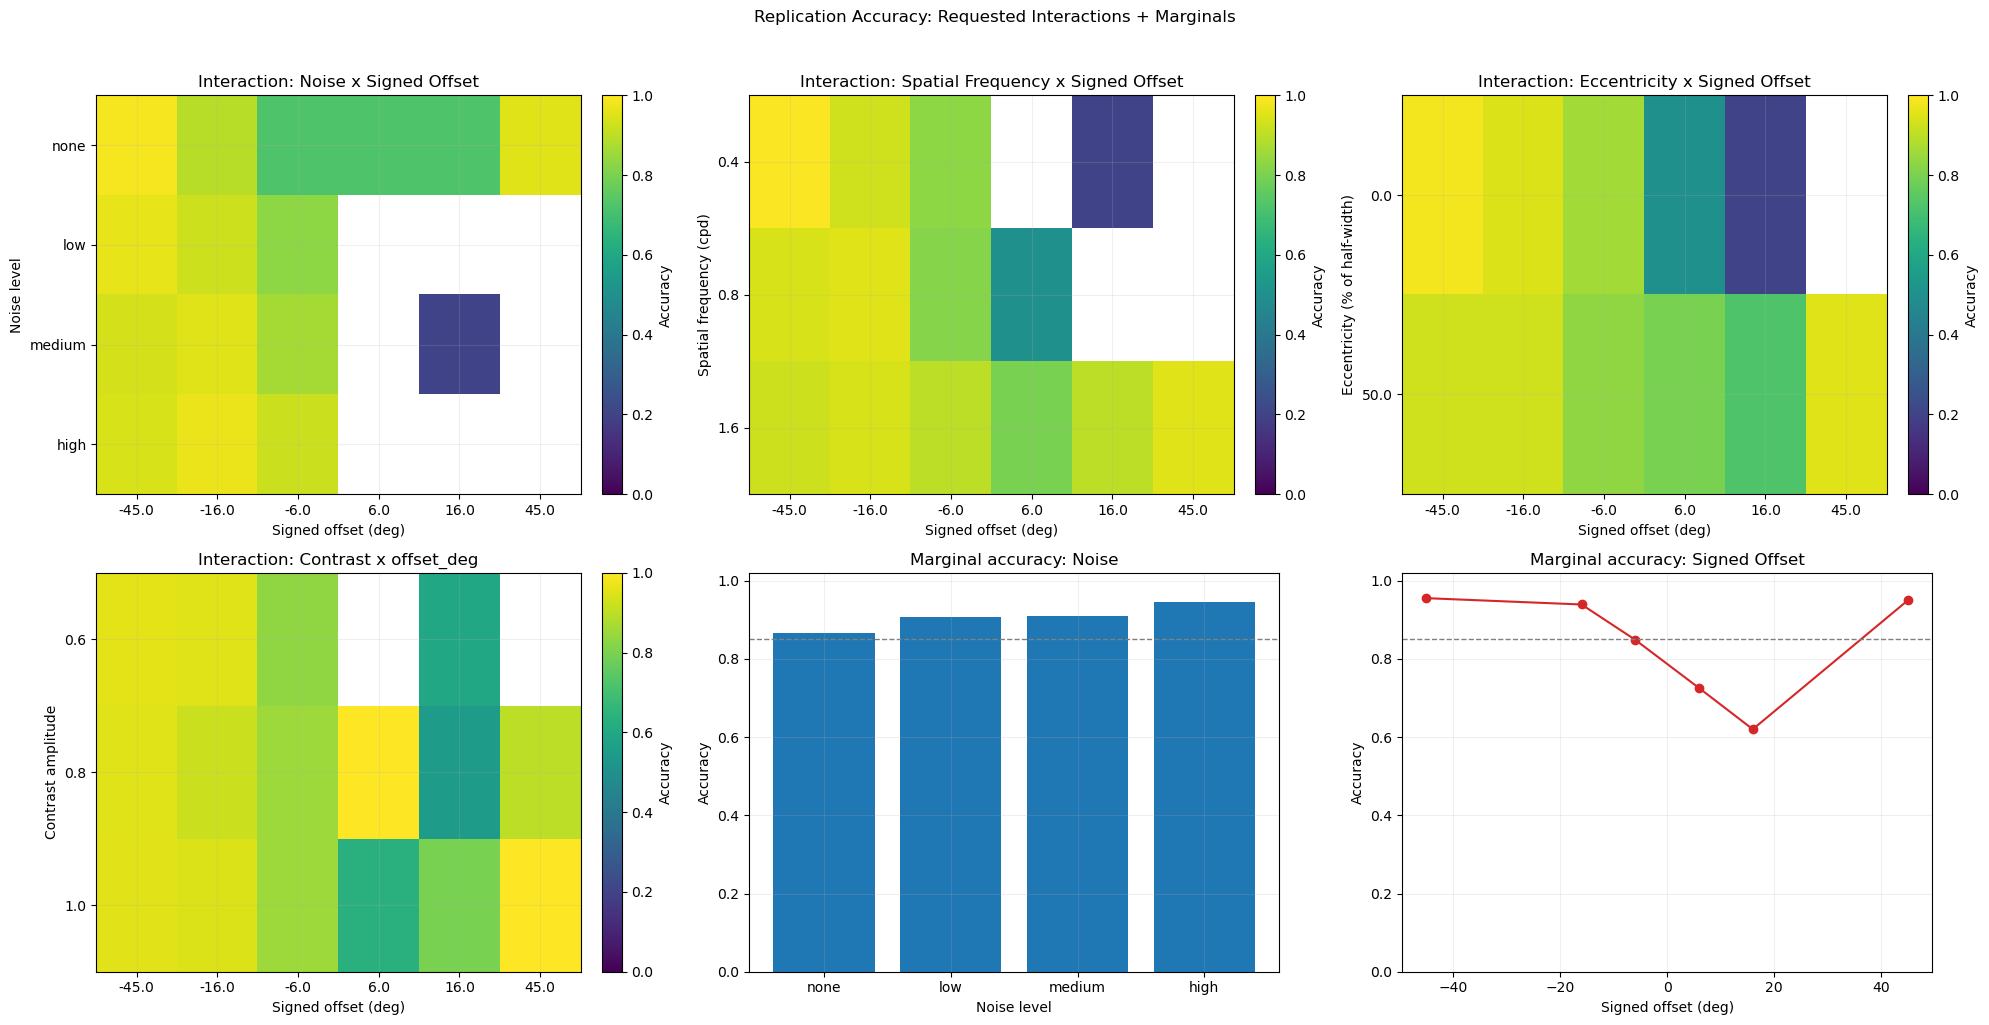

In [14]:
# Replication dashboard: requested interactions + marginals
output_dir = Path("results/claude_sonnet45_gabor_notebook")
replication_summary_path = output_dir / "replication_summary_high_performing.csv"

if not replication_summary_path.exists():
    raise FileNotFoundError(
        f"Could not find {replication_summary_path}. Run the replication cell first."
    )

rep = pd.read_csv(replication_summary_path)
if rep.empty:
    raise ValueError("Replication summary is empty; nothing to visualize.")

required_cols = {
    "eccentricity_pct", "noise_level", "spatial_freq_cpd", "contrast_amplitude",
    "offset_deg", "accuracy", "successes", "n_valid"
}
missing = required_cols.difference(rep.columns)
if missing:
    raise ValueError(f"Replication summary is missing columns: {sorted(missing)}")

GOOD_ACC = 0.85
noise_order_default = ["none", "low", "medium", "high", "very_high"]
noise_levels_present = rep["noise_level"].dropna().astype(str).unique().tolist()
noise_order = [n for n in noise_order_default if n in noise_levels_present]
noise_order += [n for n in sorted(noise_levels_present) if n not in noise_order]

def weighted_accuracy_by(group_cols):
    g = rep.groupby(group_cols, as_index=False)[["successes", "n_valid"]].sum()
    g["accuracy"] = g["successes"] / g["n_valid"]
    return g

def prep_heatmap(row_col, col_col):
    hm = weighted_accuracy_by([row_col, col_col]).copy()
    if row_col == "noise_level":
        hm[row_col] = pd.Categorical(hm[row_col], categories=noise_order, ordered=True)
    if col_col == "noise_level":
        hm[col_col] = pd.Categorical(hm[col_col], categories=noise_order, ordered=True)
    hm = hm.sort_values([row_col, col_col])
    return hm.pivot(index=row_col, columns=col_col, values="accuracy")

# Requested interaction plots
pivot_noise_offset = prep_heatmap("noise_level", "offset_deg")
pivot_freq_offset = prep_heatmap("spatial_freq_cpd", "offset_deg")
pivot_ecc_offset = prep_heatmap("eccentricity_pct", "offset_deg")
pivot_noise_contrast = prep_heatmap("contrast_amplitude", "offset_deg")

# Requested marginals
marg_noise = weighted_accuracy_by(["noise_level"]).set_index("noise_level").reindex(noise_order).reset_index()
marg_offset = weighted_accuracy_by(["offset_deg"]).sort_values("offset_deg")

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

heatmaps = [
    (pivot_noise_offset, "Noise x Signed Offset", "Signed offset (deg)", "Noise level"),
    (pivot_freq_offset, "Spatial Frequency x Signed Offset", "Signed offset (deg)", "Spatial frequency (cpd)"),
    (pivot_ecc_offset, "Eccentricity x Signed Offset", "Signed offset (deg)", "Eccentricity (% of half-width)"),
    (pivot_noise_contrast, "Contrast x offset_deg", "Signed offset (deg)", "Contrast amplitude"),
]

for idx, (pivot_df, title, xlabel, ylabel) in enumerate(heatmaps):
    im = axes[idx].imshow(pivot_df.values, aspect="auto", vmin=0, vmax=1, cmap="viridis")
    axes[idx].set_title(f"Interaction: {title}")
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel(ylabel)
    axes[idx].set_xticks(np.arange(len(pivot_df.columns)))
    axes[idx].set_xticklabels([str(c) for c in pivot_df.columns])
    axes[idx].set_yticks(np.arange(len(pivot_df.index)))
    axes[idx].set_yticklabels([str(i) for i in pivot_df.index])
    plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04, label="Accuracy")

# Marginal: noise
x_noise = np.arange(len(marg_noise))
axes[4].bar(x_noise, marg_noise["accuracy"], color="tab:blue")
axes[4].set_xticks(x_noise)
axes[4].set_xticklabels(marg_noise["noise_level"])
axes[4].set_ylim(0, 1.02)
axes[4].set_title("Marginal accuracy: Noise")
axes[4].set_xlabel("Noise level")
axes[4].set_ylabel("Accuracy")
axes[4].axhline(GOOD_ACC, linestyle="--", color="gray", linewidth=1)

# Marginal: signed offset
axes[5].plot(marg_offset["offset_deg"], marg_offset["accuracy"], marker="o", color="tab:red")
axes[5].set_ylim(0, 1.02)
axes[5].set_title("Marginal accuracy: Signed Offset")
axes[5].set_xlabel("Signed offset (deg)")
axes[5].set_ylabel("Accuracy")
axes[5].axhline(GOOD_ACC, linestyle="--", color="gray", linewidth=1)

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle("Replication Accuracy: Requested Interactions + Marginals", y=1.02)
plt.tight_layout()
plt.show()